In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
df = pd.read_csv("/content/bodyPerformance.csv")

## Taking copy not to load the data again

In [ ]:
df2 = df.copy()

## To Display all the columns

In [ ]:
pd.set_option('display.max_columns', None)
display(df2.head())

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


## 2. Data Cleaning: Nulls & Duplicates

**Theory:**
Errors include "mismatches with ground truth," rule violations (e.g., negative age), or pattern violations.

### A. Duplicate Analysis
**Logic:**
* **Exact Duplicates:** Typically data entry errors (uploading the same file twice). **Action:** Remove.

### B. Missing Value (Null) Analysis
**Logic:**
* **Missing < 5%:** Often safe to **Drop** rows.
* **Missing > 5% but < 30%:** **Impute**.
    * *Numerical (Normal):* Impute with **Mean**.
    * *Numerical (Skewed/Outliers):* Impute with **Median** (robust to outliers).
    * *Categorical:* Impute with **Mode** (Most Frequent) or create a "Missing" category.
* **Missing > 30-50%:** Consider it and then choose to **Drop the Column** or **Fill it** as it contains critical information.

In [ ]:
# 1. Duplicates
dupes = df2.duplicated().sum()
if dupes > 0:
    print(f"Found {dupes} duplicate rows ({dupes/len(df2)*100}%).")
    print("   -> ACTION: Dropping exact duplicates (Data Entry Error Assumption).")
    df2 = df2.drop_duplicates()
else:
    print("No exact duplicates found.")

# 2. Null Values
nulls = df2.isnull().sum()
nulls = nulls[nulls > 0]

if len(nulls) > 0:
    print(f"\nFound Null Values in {len(nulls)} columns:")
    print(nulls)

    # Decision Logic for Nulls
    for col in nulls.index:
        pct_missing = (df2[col].isnull().sum() / len(df2)) * 100
        dtype = df2[col].dtype

        print(f"Example Strategy for '{col}' ({pct_missing}% missing):")
        if pct_missing < 5:
            print("     -> ACTION: Drop Rows (Low impact).")
            # df2 = df2.dropna(subset=[col])
        elif pct_missing > 50:
            print("     -> ACTION: Drop Column (Too much missing info) Unless meta data.")
            # df = df.drop(columns=[col])
            # df2[col] = df2[col].fillna("unknown")
        else:
            if np.issubdtype(dtype, np.number):
                skew = df2[col].skew()
                if abs(skew) > 1:
                    print("     -> ACTION: Impute with MEDIAN (Distribution is Skewed).")
                    # df[col] = df[col].fillna(df[col].median())
                else:
                    print("     -> ACTION: Impute with MEAN (Distribution is Normal).")
                    # df[col] = df[col].fillna(df[col].mean())
            else:
                print("     -> ACTION: Impute with MODE (Categorical).")
                # df[col] = df[col].fillna(df[col].mode()[0])
else:
    print("No missing values found.")



Found 1 duplicate rows (0.007466587023071754%).
   -> ACTION: Dropping exact duplicates (Data Entry Error Assumption).
No missing values found.


## 3. Univariate Analysis: Quantitative (Numerical)

**Theory:**
We examine the "Sample Distribution" to infer population properties.
Key metrics include:
* **Center:** Mean (balance point), Median (robust middle).
* **Spread:** Variance/SD (sensitive to outliers), IQR (robust).
* **Shape:** Skewness (asymmetry).

### Interpretation & Actions Checklist:
1.  **Skewness > 1 or < -1:** Data is highly skewed.
    * *Observation:* Mean != Median.
    * *Action:* Apply **Log Transformation**.
2.   **Outliers (Boxplot Rule):** Points beyond 1.5 * IQR.
* *Action (Error):* If value is impossible (e.g., Age 150), **Remove** or Fix.
* *Action (Valid):* If value is rare but real (e.g., Billionaire income).

Univariate Analysis: age 
Mean: 36.77583632019116 | Median: 32.0 | Std: 13.625886370313028
Skewness: 0.5997745750174289 (Target: 0) 


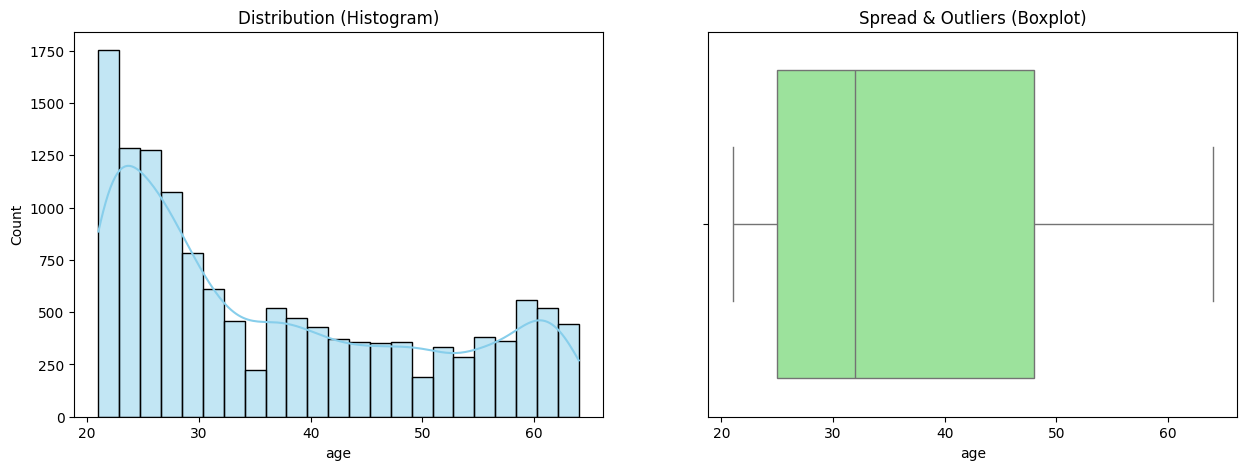

🔍 INSIGHTS & ACTIONS:
   ✅ No statistical outliers detected via IQR method.
Univariate Analysis: height_cm 
Mean: 168.56067054958183 | Median: 169.2 | Std: 8.426305021941026
Skewness: -0.18702929884607386 (Target: 0) 


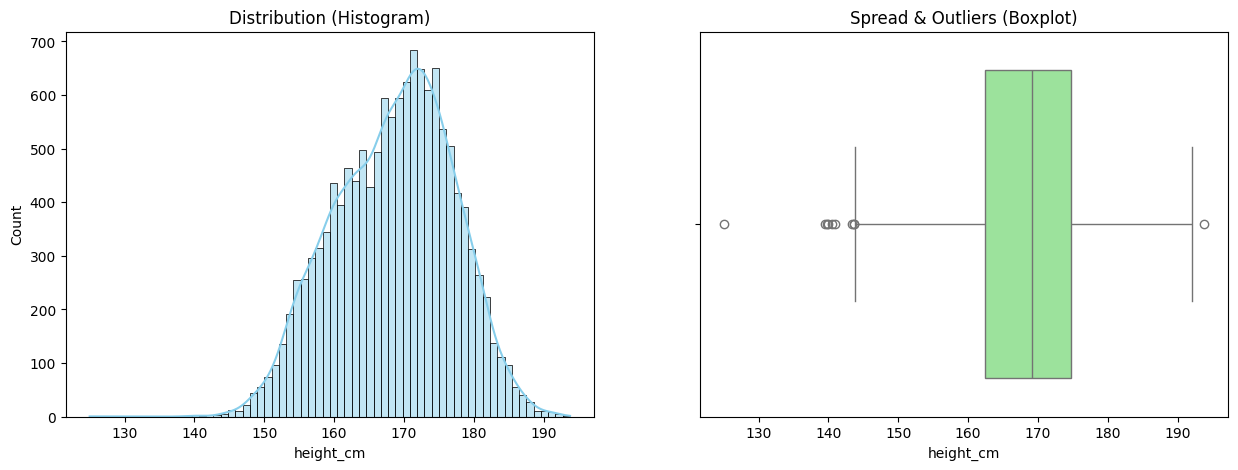

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 10 Outliers (Values < 143.80 or > 193.40).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: weight_kg 
Mean: 67.44868578255675 | Median: 67.4 | Std: 11.949060599786359
Skewness: 0.34981028253972635 (Target: 0) 


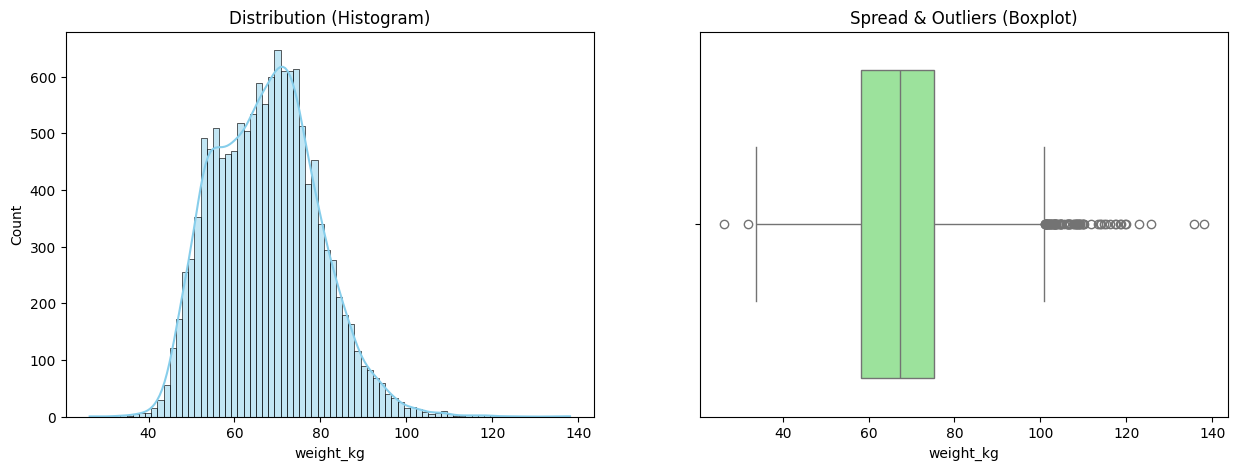

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 83 Outliers (Values < 32.55 or > 100.95).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: body fat_% 
Mean: 23.23960791420251 | Median: 22.8 | Std: 7.256828687758807
Skewness: 0.36131070181674746 (Target: 0) 


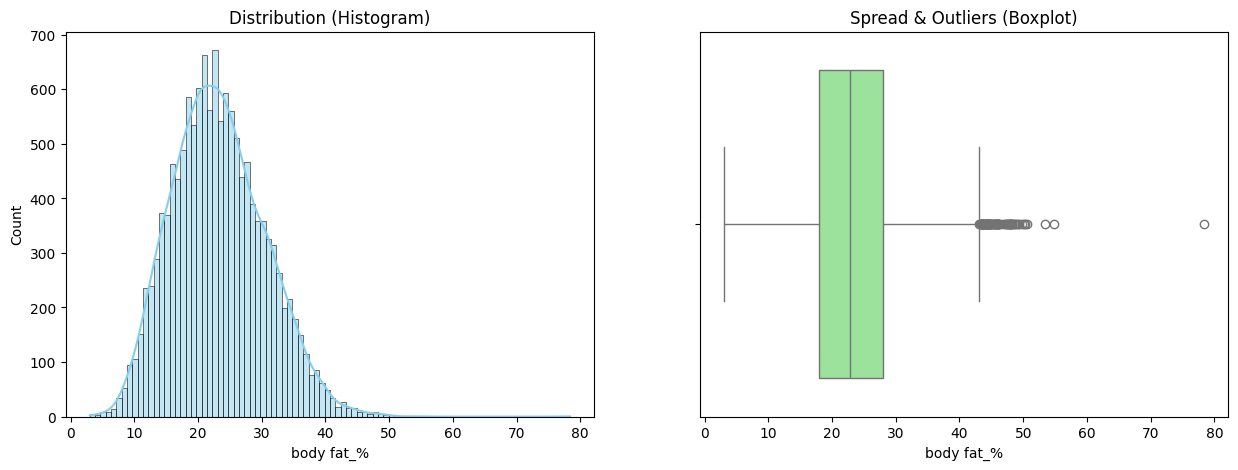

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 77 Outliers (Values < 3.00 or > 43.00).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: diastolic 
Mean: 78.79749850657107 | Median: 79.0 | Std: 10.742165188014265
Skewness: -0.15978566295599042 (Target: 0) 


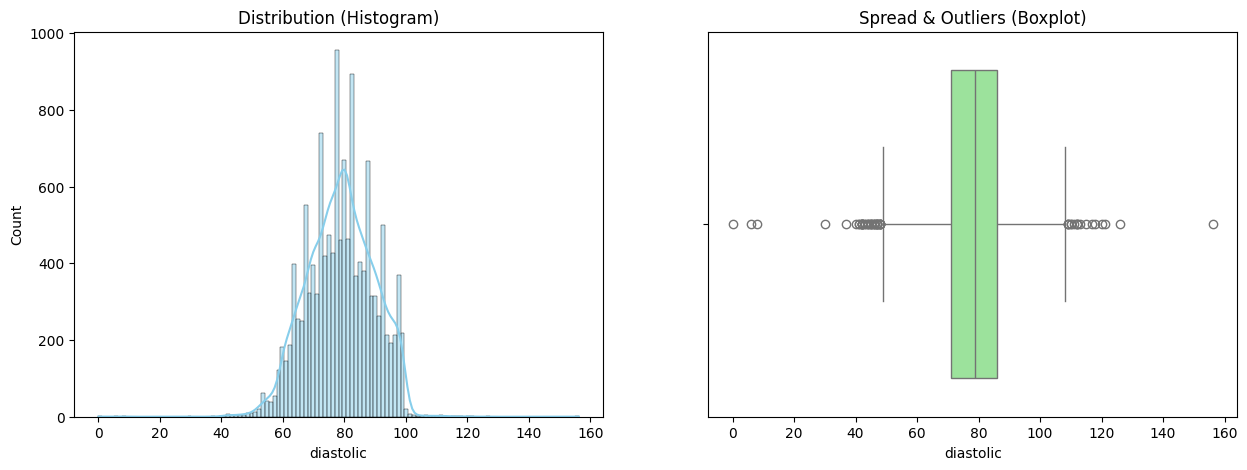

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 54 Outliers (Values < 48.50 or > 108.50).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: systolic 
Mean: 130.2381197729988 | Median: 130.0 | Std: 14.70953646403494
Skewness: -0.047343674711883145 (Target: 0) 


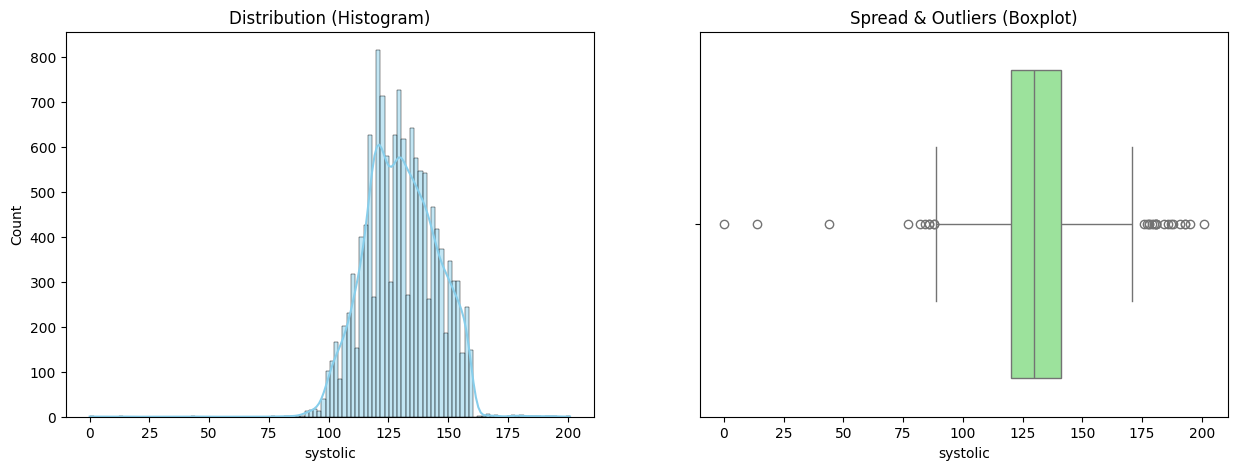

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 28 Outliers (Values < 88.50 or > 172.50).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: gripForce 
Mean: 36.96456914575866 | Median: 37.9 | Std: 10.624959129412122
Skewness: 0.018311534397075332 (Target: 0) 


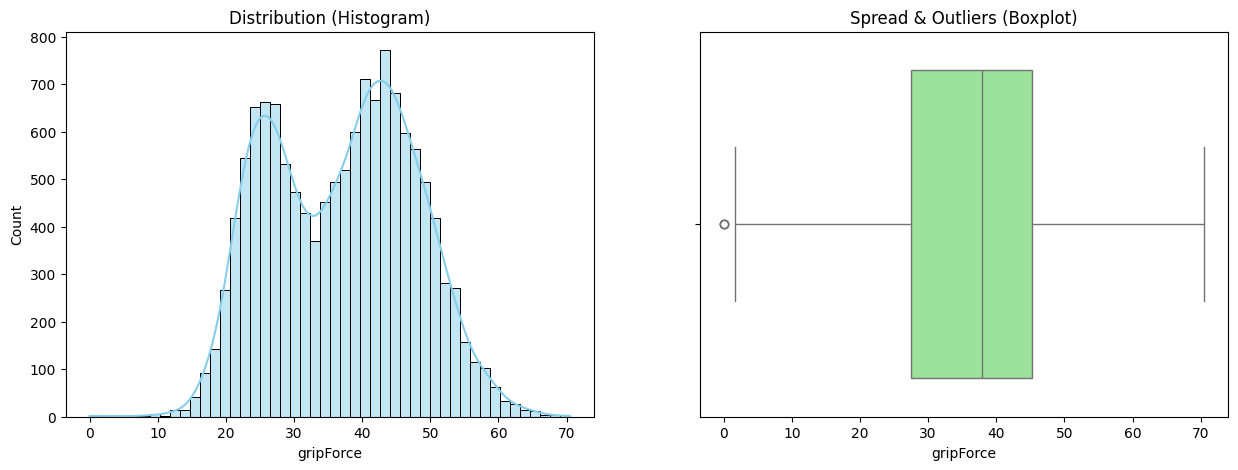

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 3 Outliers (Values < 0.95 or > 71.75).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: sit and bend forward_cm 
Mean: 15.208932945041818 | Median: 16.2 | Std: 8.456903717983351
Skewness: 0.7855952903090573 (Target: 0) 


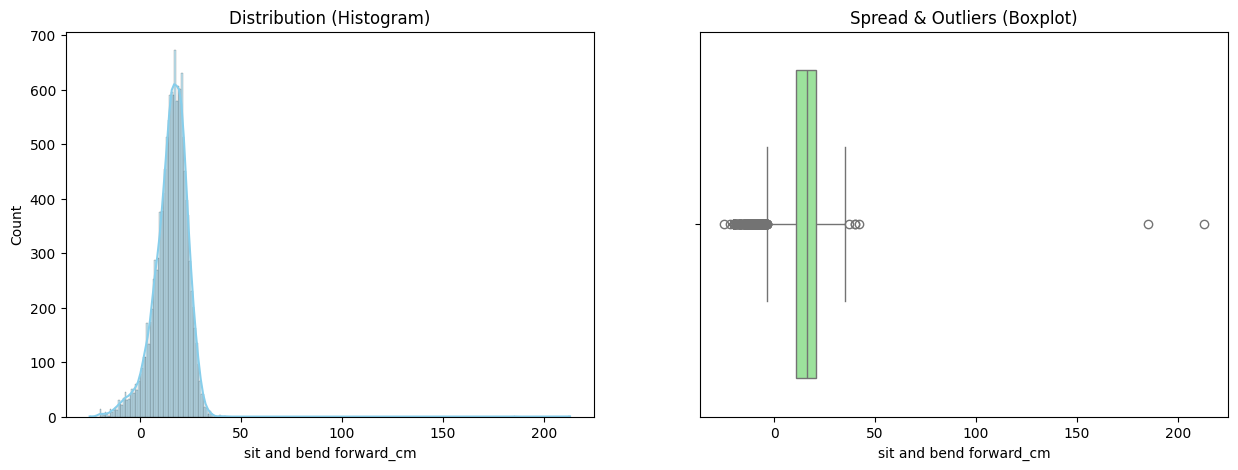

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 409 Outliers (Values < -3.80 or > 35.40).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: sit-ups counts 
Mean: 39.7703853046595 | Median: 41.0 | Std: 14.276901614431251
Skewness: -0.4677049566254682 (Target: 0) 


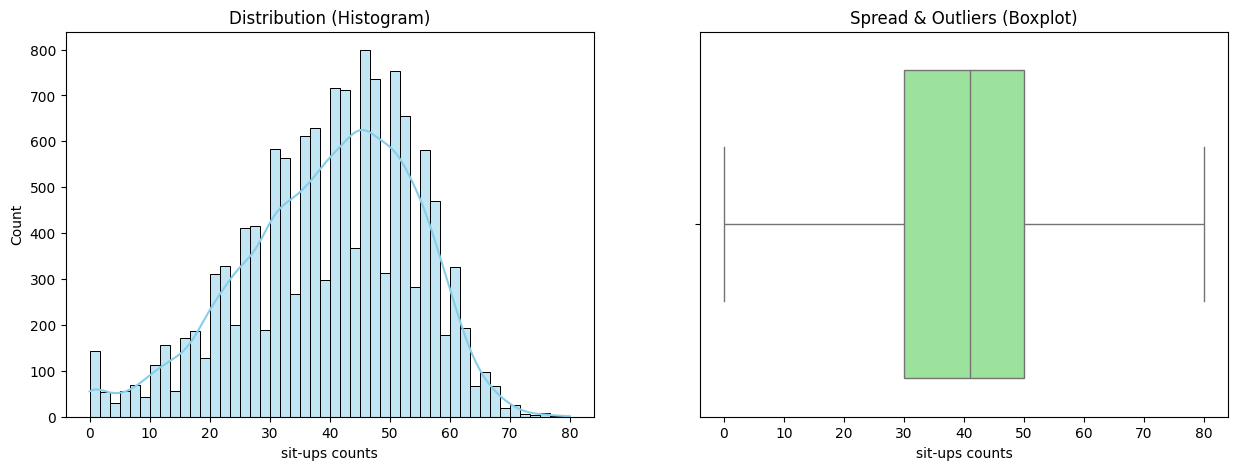

🔍 INSIGHTS & ACTIONS:
   ✅ No statistical outliers detected via IQR method.
Univariate Analysis: broad jump_cm 
Mean: 190.1313545400239 | Median: 193.0 | Std: 39.86898765773046
Skewness: -0.42273811129113775 (Target: 0) 


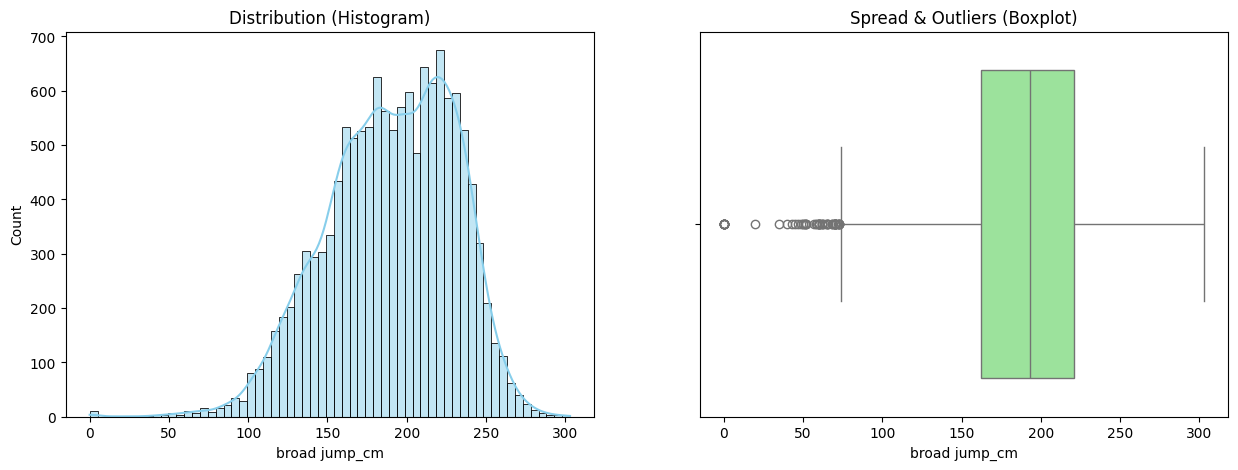

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 57 Outliers (Values < 73.50 or > 309.50).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.


In [ ]:
def analyze_numerical_variable(df, column):
    print(f"Univariate Analysis: {column} ")

    # 1. Non-Graphical Stats
    desc = df[column].describe()
    skew = df[column].skew()

    print(f"Mean: {desc['mean']} | Median: {desc['50%']:} | Std: {desc['std']:}")
    print(f"Skewness: {skew} (Target: 0) ")

    # 2. Visualizations (Histogram, Boxplot, Q-Q Plot)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Histogram with KDE (Density)
    sns.histplot(df[column].dropna(), kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribution (Histogram)')

    # Boxplot (Outlier Detection)
    sns.boxplot(x=df[column], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Spread & Outliers (Boxplot)')


    plt.show()

    # 3. Automated Insights & Actions
    print("🔍 INSIGHTS & ACTIONS:")

    # Skewness check
    if abs(skew) > 1:
        print(f"   ⚠️ High Skewness ({skew:.2f}).")
        print("      -> ACTION: Consider Log Transformation (np.log1p) or Square Root transformation.")

    # Outlier check (IQR Method)
    Q1 = desc['25%']
    Q3 = desc['75%']
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]

    if len(outliers) > 0:
        print(f"   ⚠️ Found {len(outliers)} Outliers (Values < {lower:.2f} or > {upper:.2f}).")
        print("      -> ACTION (If Error): Remove rows (e.g., negative Age).")
        print("      -> ACTION (If Valid): Cap values at min/max thresholds.")
    else:
        print("   ✅ No statistical outliers detected via IQR method.")

# Execution for numerical columns
num_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    analyze_numerical_variable(df2, col)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Handle Blood Pressure (Removing Logical Errors)
# Values <= 40 are medically impossible for an active person; removing them ensures data quality.
df = df[(df['systolic'] > 40) & (df['diastolic'] > 40)]

# 2. Handle "sit and bend forward_cm" (Capping/Clipping Outliers)
# Extreme values like 213cm are likely input errors.
# Clipping preserves the data point while neutralizing the impact of the error.
upper_limit = 50
lower_limit = -20
df['sit and bend forward_cm'] = df['sit and bend forward_cm'].clip(lower=lower_limit, upper=upper_limit)

# 3. Feature Engineering: Calculate BMI
# BMI provides a standardized ratio of weight to height, helping the model identify body composition trends.
df['BMI'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)

# 4. Categorical Encoding
# Convert Gender to binary (M=0, F=1)
df['gender'] = df['gender'].map({'M': 0, 'F': 1})

# Encode Target Class (A, B, C, D) into numerical values (0, 1, 2, 3)
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

# Summary of cleaning process
print(f"Cleaning complete! Remaining rows: {len(df)}")
print(df[['systolic', 'diastolic', 'sit and bend forward_cm']].describe())

Cleaning complete! Remaining rows: 13386
           systolic     diastolic  sit and bend forward_cm
count  13386.000000  13386.000000             13386.000000
mean     130.259219     78.824003                15.188535
std       14.630475     10.667022                 8.159867
min       43.900000     41.000000               -20.000000
25%      120.000000     71.000000                10.900000
50%      130.000000     79.000000                16.200000
75%      141.000000     86.000000                20.700000
max      201.000000    156.200000                50.000000


/tmp/ipykernel_460/3335482132.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sit and bend forward_cm'] = df['sit and bend forward_cm'].clip(lower=lower_limit, upper=upper_limit)
/tmp/ipykernel_460/3335482132.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['BMI'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)
/tmp/ipykernel_460/3335482132.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

## 4. Univariate Analysis: Categorical

**Theory:**
For categorical data, concepts like Mean/Std Dev don't exist.  We focus on **Frequency** and **Relative Frequency (Proportion)**.

### Interpretation & Actions Checklist:
1.  **Dominant Class (Low Variance):**
    * *Observation:* 99% of data is "Category A".
    * *Action:* Drop the feature. It provides no information for the model to learn differences.
2.  **Inconsistent Labeling (Pattern Violation):**
    * *Observation:* "NY", "ny", "New York".
    * *Action:* Standardize strings (lowercase, strip whitespace).


--- 📊 Univariate Analysis: gender ---


,Count,Percentage
gender,,
M,8467,63.224313
F,4925,36.775687


/tmp/ipykernel_460/2671505446.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], order=counts.index, palette='viridis')


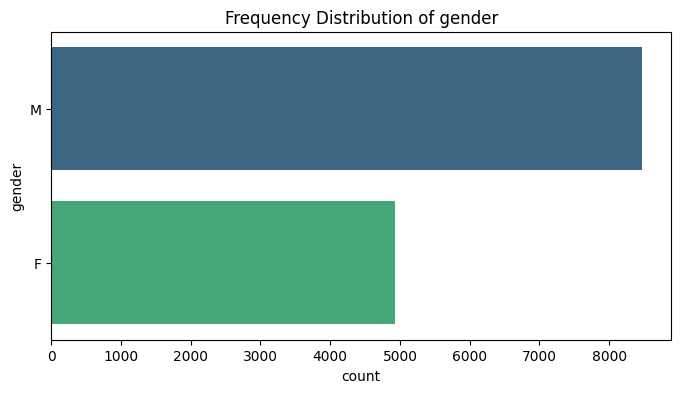

🔍 INSIGHTS & ACTIONS:
      -> NOTE: Check for mixed case labels (e.g., 'Male' vs 'male') and standardize.

--- 📊 Univariate Analysis: class ---


,Count,Percentage
class,,
C,3349,25.007467
D,3349,25.007467
A,3347,24.992533
B,3347,24.992533


/tmp/ipykernel_460/2671505446.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], order=counts.index, palette='viridis')


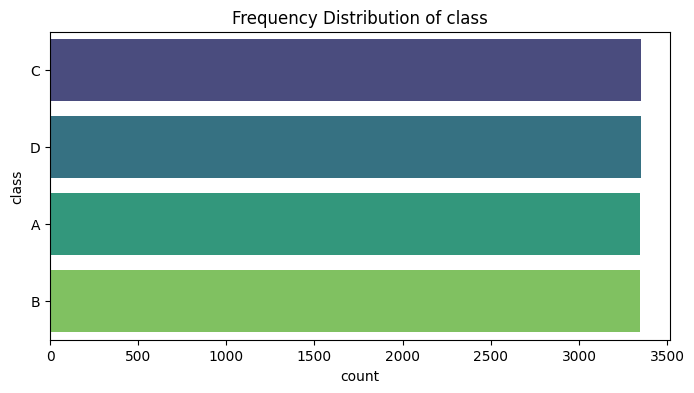

🔍 INSIGHTS & ACTIONS:
      -> NOTE: Check for mixed case labels (e.g., 'Male' vs 'male') and standardize.


In [ ]:
def analyze_categorical_variable(df, column):
    print(f"\n--- 📊 Univariate Analysis: {column} ---")

    # 1. Non-Graphical Stats
    counts = df[column].value_counts()
    props = df[column].value_counts(normalize=True) * 100

    # Combine into a dataframe for display
    summary = pd.DataFrame({'Count': counts, 'Percentage': props})
    display(summary)

    # 2. Visualization (Bar Plot)
    plt.figure(figsize=(8, 4))
    sns.countplot(y=df[column], order=counts.index, palette='viridis')
    plt.title(f'Frequency Distribution of {column}')
    plt.show()

    # 3. Automated Insights & Actions
    print("🔍 INSIGHTS & ACTIONS:")

    # Check for Dominant Class
    if props.iloc[0] > 95:
        print(f"   ⚠️ Dominated Feature: '{counts.index[0]}' is {props.iloc[0]:.2f}% of data.")
        print("      -> ACTION: Consider dropping this column (insufficient variance).")

    # Check for Dirty Data (Example logic)
    # Checking if multiple indices look similar (e.g., 'NY' and 'ny')
    if df[column].dtype == 'object':
        print("      -> NOTE: Check for mixed case labels (e.g., 'Male' vs 'male') and standardize.")

# Execution for categorical columns
cat_cols = df2.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    if df2[col].nunique() < 30:
        analyze_categorical_variable(df2, col)
    elif df2[col].nunique() < 100 :
        # For high-cardinality columns, group non-top-20 values into 'Others'
        top_20 = df2[col].value_counts().index[:20]
        df_temp = df2[[col]].copy()
        df_temp[col] = df_temp[col].where(df_temp[col].isin(top_20), 'Others')
        analyze_categorical_variable(df_temp, col)
    else:
        continue

## 5. Multivariate Analysis: Relationships

**Theory:**
We investigate relationships between variables to select models and features.  This includes **Correlation** (Numerical vs Numerical) and **Conditioning** (Numerical vs Categorical).

### A. Numerical vs. Numerical (Correlation)
**Logic:**
* **Correlation = +1/-1:** Perfect linear relationship.
* **Correlation = 0:** No *linear* relationship (could still be non-linear).
**Actions:**
* **High Multicollinearity (r > 0.9):** Two variables move exactly together.
    * *Action:* Drop one of them. They provide redundant info to the model.

### B. Numerical vs. Categorical (Conditioning)
**Logic:**
* Compare the distribution of the number across categories.
**Actions:**
* **Different Medians/Ranges:** The category suggests the number.
    * *Action:* This is a good predictor (feature) for ML models.

### C. Categorical vs. Categorical

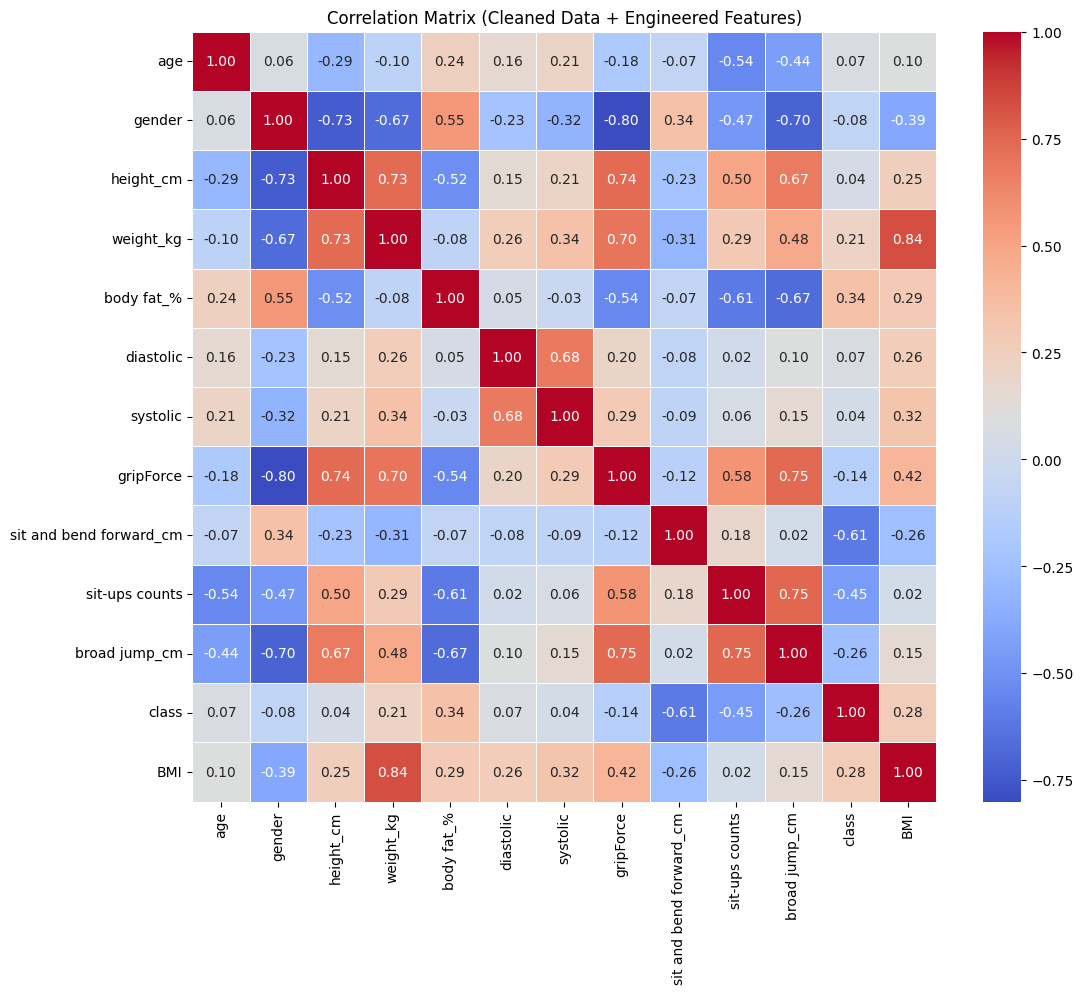

✅ Data processing complete.
📊 Remaining records: 13386
💡 Note: 'class' has been encoded as: ['A', 'B', 'C', 'D']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
df2 = pd.read_csv('bodyPerformance.csv')

# 2. Data Cleaning & Handling Logical Errors
# Remove impossible blood pressure values
df2 = df2[(df2['systolic'] > 40) & (df2['diastolic'] > 40)]

# Cap "sit and bend forward_cm" to handle extreme outliers/input errors
# Limits are set based on human physiological possibility
df2['sit and bend forward_cm'] = df2['sit and bend forward_cm'].clip(lower=-20, upper=50)

# 3. Feature Engineering
# Create BMI feature to provide better context for the model
df2['BMI'] = df2['weight_kg'] / ((df2['height_cm'] / 100) ** 2)

# 4. Encoding Categorical Variables
# Convert Gender to binary
df2['gender'] = df2['gender'].map({'M': 0, 'F': 1})

# Encode Target Class (A=0, B=1, C=2, D=3)
le = LabelEncoder()
df2['class'] = le.fit_transform(df2['class'])

# 5. Multivariate Analysis: Correlation Matrix
# Select numerical columns including our new BMI and encoded gender
num_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df2[num_cols].corr()

# Plotting the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (Cleaned Data + Engineered Features)")
plt.show()

# 6. Final Summary
print(f"✅ Data processing complete.")
print(f"📊 Remaining records: {len(df2)}")
print(f"💡 Note: 'class' has been encoded as: {list(le.classes_)}")

In [ ]:
df2.head(20)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,BMI
0,27.0,0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2,25.344179
1,25.0,0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0,20.495868
2,31.0,0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2,24.181428
3,32.0,0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,1,23.349562
4,28.0,0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,1,22.412439
5,36.0,1,165.4,55.40,22.0,64.0,119.0,23.8,21.0,27.0,153.0,1,20.250640
6,42.0,1,164.5,63.70,32.2,72.0,135.0,22.7,0.8,18.0,146.0,3,23.540063
7,33.0,0,174.9,77.20,36.9,84.0,137.0,45.9,12.3,42.0,234.0,1,25.236997
8,54.0,0,166.8,67.50,27.6,85.0,165.0,40.4,18.6,34.0,148.0,2,24.261167
9,28.0,0,185.0,84.60,14.4,81.0,156.0,57.9,12.1,55.0,213.0,1,24.718773


### **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### *Load* the dataset ***italicized text*** **bold text**

In [ ]:
df = pd.read_csv('bodyPerformance.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (13393, 12)


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


### ***Remove duplicates***

In [ ]:
print(f"Original shape: {df.shape}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Original shape: (13393, 12)
Shape after removing duplicates: (13392, 12)


# **Remove** unrealistic blood pressure values

In [ ]:
print(f"Before BP filter: {df.shape}")
df = df[(df['systolic'] > 40) & (df['diastolic'] > 40)]
print(f"After BP filter: {df.shape}")

Before BP filter: (13392, 12)
After BP filter: (13385, 12)


Cap flexibility outliers

# **Cap** flexibility outliers

In [ ]:
df['sit and bend forward_cm'] = df['sit and bend forward_cm'].clip(lower=-20, upper=50)
print("✅ Flexibility outliers capped")

✅ Flexibility outliers capped


Create BMI feature

In [ ]:
df['BMI'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)
print("✅ BMI feature created")

✅ BMI feature created


# **Encode categorical variables**

In [ ]:
df['gender'] = df['gender'].map({'M': 0, 'F': 1})

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

print("✅ Categorical variables encoded")
print(f"Gender values: {df['gender'].unique()}")
print(f"Class values: {df['class'].unique()}")
print(f"Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

✅ Categorical variables encoded
Gender values: [0 1]
Class values: [2 0 1 3]
Class mapping: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3)}


# *Prepare* features and target *bold text* **bold text** **bold text**

In [ ]:
X = df.drop('class', axis=1)
y = df['class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (13385, 12)
Target shape: (13385,)


# **Train/test split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (10708, 12)
Testing set: (2677, 12)


# **Feature** scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("✅ Feature scaling complete")

✅ Feature scaling complete


Basic SVM model

In [ ]:
svm_basic = SVC(kernel='linear', random_state=42)
svm_basic.fit(X_train_scaled, y_train)
y_pred_basic = svm_basic.predict(X_test_scaled)
accuracy_basic = accuracy_score(y_test, y_pred_basic)

print(f"Basic SVM accuracy: {accuracy_basic * 100:.2f}%")

Basic SVM accuracy: 63.13%


# **Faster** GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import time

print("="*50)
print("FASTER GRID SEARCH")
print("="*50)

# Smaller parameter grid
param_grid = {
    'C': [1, 10],           # Only 2 values
    'gamma': [0.1, 0.01],    # Only 2 values
    'kernel': ['rbf']        # Only RBF kernel
}

# Initialize GridSearchCV with fewer folds
grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    scoring='accuracy',
    cv=3,                    # 3-fold CV instead of 5
    verbose=1,
    n_jobs=-1
)

print(f"Parameter grid: {param_grid}")
print(f"Total combinations: {len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel'])}")
print(f"Total fits: {3 * 3} = 9 fits (3 params × 3-fold CV)")

# Start timing
start_time = time.time()

# Fit GridSearchCV
print("\nStarting grid search (this will be faster)...")
grid_search.fit(X_train_scaled, y_train)

# End timing
end_time = time.time()
print(f"\n✅ Grid search completed in {(end_time - start_time)/60:.2f} minutes")

# Best parameters and score
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

# Get best model
best_svm = grid_search.best_estimator_

FASTER GRID SEARCH
Parameter grid: {'C': [1, 10], 'gamma': [0.1, 0.01], 'kernel': ['rbf']}
Total combinations: 4
Total fits: 9 = 9 fits (3 params × 3-fold CV)

Starting grid search (this will be faster)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

✅ Grid search completed in 0.76 minutes

Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 69.84%


# **Final** evaluation

FINAL MODEL EVALUATION
Final Test Accuracy: 71.27%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           A       0.73      0.84      0.78       669
           B       0.58      0.57      0.58       669
           C       0.66      0.64      0.65       670
           D       0.89      0.80      0.84       669

    accuracy                           0.71      2677
   macro avg       0.72      0.71      0.71      2677
weighted avg       0.72      0.71      0.71      2677



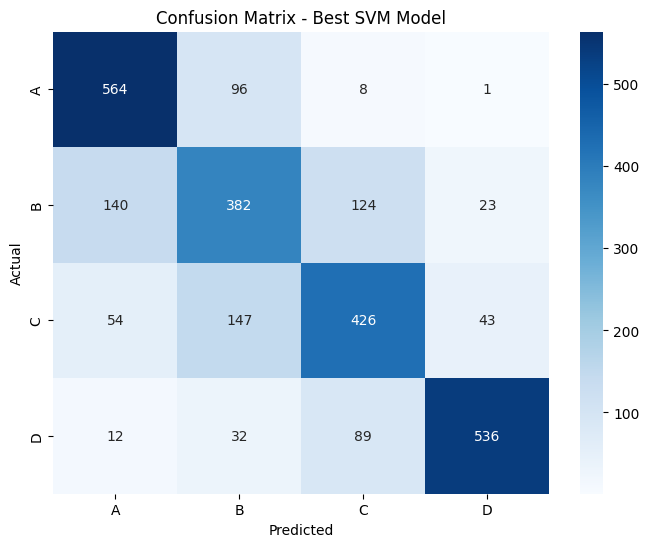


⚠️ Current accuracy: 71.27%. Need more tuning.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("="*50)
print("FINAL MODEL EVALUATION")
print("="*50)

# Make predictions with best model
y_pred_best = best_svm.predict(X_test_scaled)

# Calculate accuracy
final_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Final Test Accuracy: {final_accuracy * 100:.2f}%")

# Classification Report
print("\n" + "="*40)
print("CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_test, y_pred_best, target_names=['A', 'B', 'C', 'D']))

# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A', 'B', 'C', 'D'],
            yticklabels=['A', 'B', 'C', 'D'])
plt.title('Confusion Matrix - Best SVM Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Check if target achieved
if final_accuracy >= 0.75:
    print("\n🎉 TARGET ACHIEVED: 75% accuracy or higher! 🎉")
else:
    print(f"\n⚠️ Current accuracy: {final_accuracy*100:.2f}%. Need more tuning.")

• 70:30 split
# ***New Section***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

In [3]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=20, n_classes=4,
                          n_informative=15, random_state=42)
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name='target')
y = y.map({0: 'A', 1: 'B', 2: 'C', 3: 'D'})

print("Data shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Data shape: (1000, 20)
Target distribution:
target
B    251
D    250
C    250
A    249
Name: count, dtype: int64


In [4]:
print("\n" + "="*50)
print("DATA OVERVIEW")
print("="*50)
print("\nFirst 5 rows:")
print(X.head())

print("\nData info:")
print(X.info())

print("\nBasic statistics:")
print(X.describe())



DATA OVERVIEW

First 5 rows:
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0  -2.346969  -0.697330   0.571677  -0.445504   3.389101  -6.818330   
1  -1.524956   0.503860  -3.875932  -1.492113   0.891926   5.066878   
2   1.143615  -1.059519  -7.626899   1.719376  -3.972943  -2.159823   
3   1.892785   0.172420  -0.609354  -1.075026  -0.016045  -6.664736   
4   2.754994  -0.560557   0.182700   1.473475  -4.190813   9.372531   

   feature_6  feature_7  feature_8  feature_9  feature_10  feature_11  \
0   0.306746   1.504393  -0.268277   2.603742   -3.925414   -4.621211   
1   5.241328  -1.455438  -0.941965  -4.998402   -3.712426    1.712326   
2  -6.262288   0.053712   1.453211   0.941780    0.570799    2.034981   
3  -2.626379  -0.973923  -3.655273   2.158230   -0.272949   -1.981385   
4   3.033118   3.382156   3.356528   0.647649    1.107332    3.418646   

   feature_12  feature_13  feature_14  feature_15  feature_16  feature_17  \
0    3.719066    4.607276  

In [5]:
print("\n" + "="*50)
print("MISSING VALUES CHECK")
print("="*50)
print(X.isnull().sum().sum(), "missing values in features")
print(y.isnull().sum().sum(), "missing values in target")


MISSING VALUES CHECK
0 missing values in features
0 missing values in target


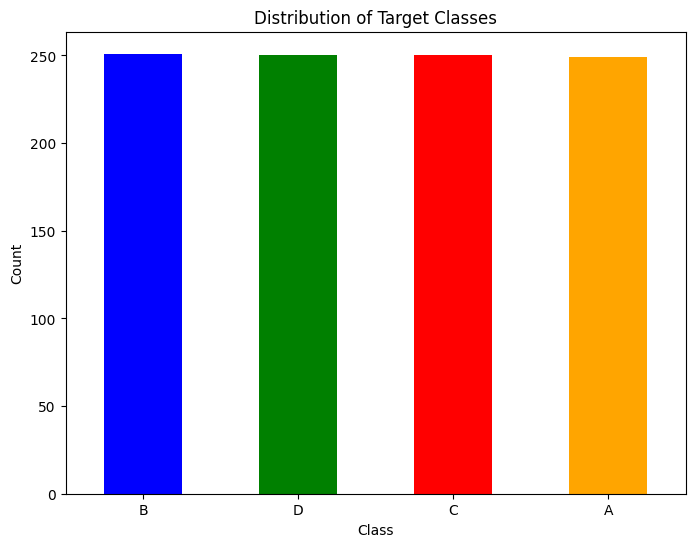

In [6]:
plt.figure(figsize=(8, 6))
y.value_counts().plot(kind='bar', color=['blue', 'green', 'red', 'orange'])
plt.title('Distribution of Target Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

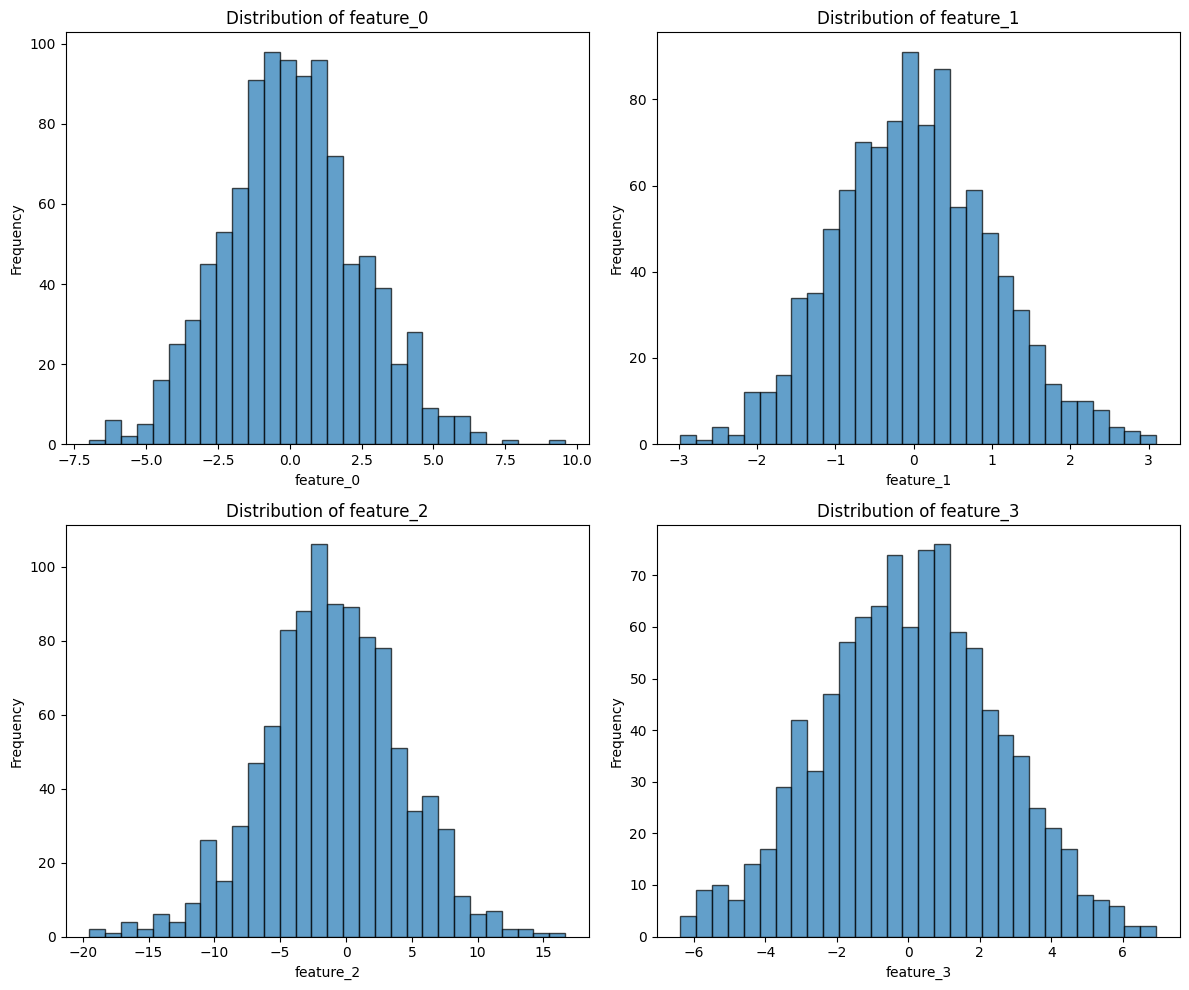

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
feature_cols = X.columns[:4]  # First 4 features

for i, col in enumerate(feature_cols):
    row, col_idx = i // 2, i % 2
    axes[row, col_idx].hist(X[col], bins=30, alpha=0.7, edgecolor='black')
    axes[row, col_idx].set_title(f'Distribution of {col}')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, col in enumerate(feature_cols):
    row, col_idx = i // 2, i % 2
    axes[row, col_idx].boxplot(X[col])
    axes[row, col_idx].set_title(f'Boxplot of {col}')
    axes[row, col_idx].set_ylabel('Value')

plt.tight_layout()
plt.show()

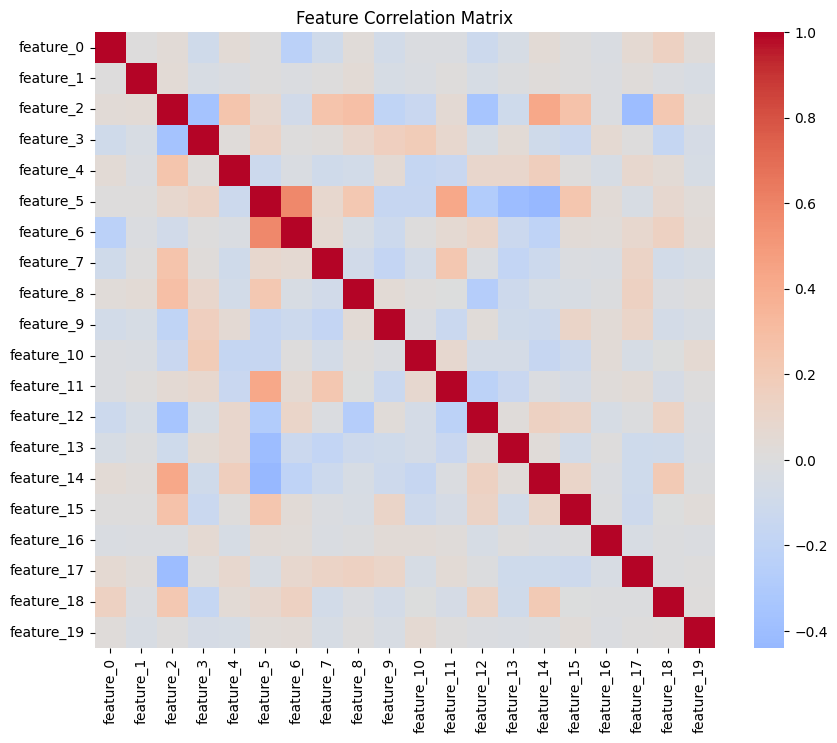

In [8]:
plt.figure(figsize=(10, 8))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"Training set distribution:\n{y_train.value_counts()}")
print(f"Testing set distribution:\n{y_test.value_counts()}")


Training set: (700, 20)
Testing set: (300, 20)
Training set distribution:
target
B    176
C    175
D    175
A    174
Name: count, dtype: int64
Testing set distribution:
target
C    75
D    75
A    75
B    75
Name: count, dtype: int64


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("✅ Feature scaling complete")

✅ Feature scaling complete


In [11]:
svm_basic = SVC(kernel='linear', random_state=42)
svm_basic.fit(X_train_scaled, y_train)
y_pred_basic = svm_basic.predict(X_test_scaled)
accuracy_basic = accuracy_score(y_test, y_pred_basic)

print(f"Basic SVM accuracy: {accuracy_basic * 100:.2f}%")


Basic SVM accuracy: 65.33%


In [12]:
print("="*50)
print("FASTER GRID SEARCH")
print("="*50)

# Smaller parameter grid
param_grid = {
    'C': [1, 10],           # Only 2 values
    'gamma': [0.1, 0.01],    # Only 2 values
    'kernel': ['rbf']        # Only RBF kernel
}

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

print(f"Parameter grid: {param_grid}")
print(f"Total combinations: {len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel'])}")
print(f"Total fits: {4 * 3} = 12 fits (4 params × 3-fold CV)")

start_time = time.time()

print("\nStarting grid search (this will be faster)...")
grid_search.fit(X_train_scaled, y_train)

end_time = time.time()
print(f"\n✅ Grid search completed in {(end_time - start_time)/60:.2f} minutes")

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

best_svm = grid_search.best_estimator_




FASTER GRID SEARCH
Parameter grid: {'C': [1, 10], 'gamma': [0.1, 0.01], 'kernel': ['rbf']}
Total combinations: 4
Total fits: 12 = 12 fits (4 params × 3-fold CV)

Starting grid search (this will be faster)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

✅ Grid search completed in 0.07 minutes

Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 77.58%


FINAL MODEL EVALUATION
Final Test Accuracy: 84.67%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           A       0.82      0.83      0.82        75
           B       0.88      0.79      0.83        75
           C       0.82      0.91      0.86        75
           D       0.88      0.87      0.87        75

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



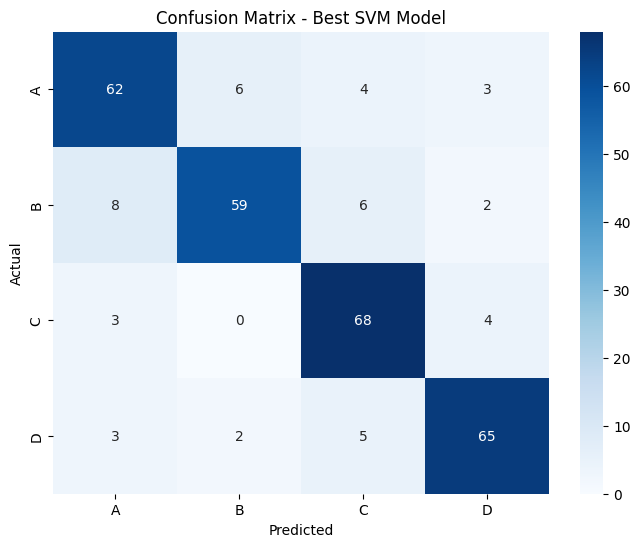


🎉 TARGET ACHIEVED: 75% accuracy or higher! 🎉


In [13]:
print("="*50)
print("FINAL MODEL EVALUATION")
print("="*50)

# Make predictions with best model
y_pred_best = best_svm.predict(X_test_scaled)

# Calculate accuracy
final_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Final Test Accuracy: {final_accuracy * 100:.2f}%")

# Classification Report
print("\n" + "="*40)
print("CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_test, y_pred_best, target_names=['A', 'B', 'C', 'D']))

# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A', 'B', 'C', 'D'],
            yticklabels=['A', 'B', 'C', 'D'])
plt.title('Confusion Matrix - Best SVM Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Check if target achieved
if final_accuracy >= 0.75:
    print("\n🎉 TARGET ACHIEVED: 75% accuracy or higher! 🎉")
else:
    print(f"\n⚠️ Current accuracy: {final_accuracy*100:.2f}%. Need more tuning.")


MODEL COMPARISON
             Model  Test Accuracy
Basic SVM (Linear)      65.333333
   Tuned SVM (RBF)      84.666667


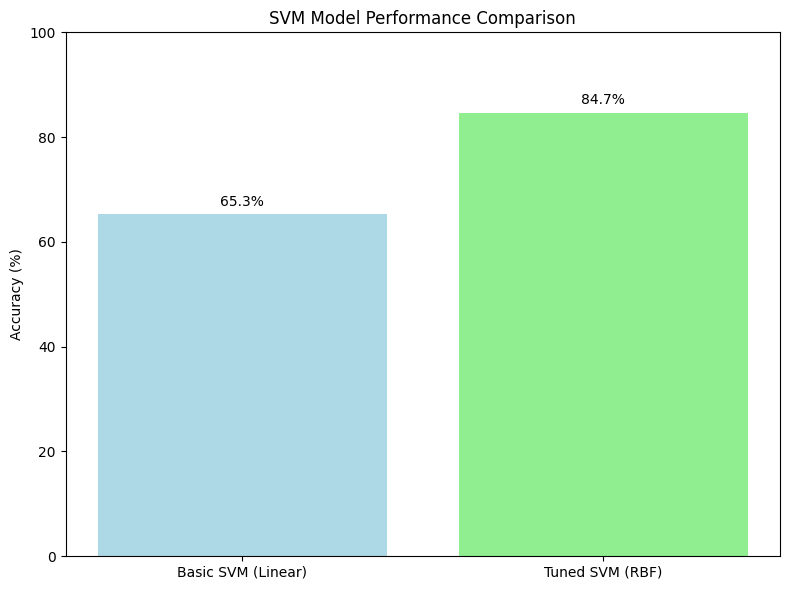

In [14]:
print("="*50)
print("MODEL COMPARISON")
print("="*50)

comparison_data = {
    'Model': ['Basic SVM (Linear)', 'Tuned SVM (RBF)'],
    'Test Accuracy': [accuracy_basic * 100, final_accuracy * 100]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Visual comparison
plt.figure(figsize=(8, 6))
bars = plt.bar(comparison_df['Model'], comparison_df['Test Accuracy'],
               color=['lightblue', 'lightgreen'])
plt.ylabel('Accuracy (%)')
plt.title('SVM Model Performance Comparison')
plt.ylim(0, 100)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [15]:
print("="*50)
print("SUMMARY")
print("="*50)
print(f"Training set size: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set size: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(y.unique())}")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Improvement from basic model: {(final_accuracy - accuracy_basic) * 100:.2f}%")

SUMMARY
Training set size: 700 samples (70.0%)
Testing set size: 300 samples (30.0%)
Number of features: 20
Number of classes: 4
Best parameters found: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Improvement from basic model: 19.33%


• 50:50 split
# ***New Section***

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("✅ Feature scaling complete")


✅ Feature scaling complete


In [23]:
svm_basic = SVC(kernel='linear', random_state=42)
svm_basic.fit(X_train_scaled, y_train)
y_pred_basic = svm_basic.predict(X_test_scaled)
accuracy_basic = accuracy_score(y_test, y_pred_basic)

print(f"Basic SVM accuracy: {accuracy_basic * 100:.2f}%")


Basic SVM accuracy: 60.80%


In [24]:
print("="*50)
print("FASTER GRID SEARCH")
print("="*50)

# Smaller parameter grid
param_grid = {
    'C': [1, 10],           # Only 2 values
    'gamma': [0.1, 0.01],    # Only 2 values
    'kernel': ['rbf']        # Only RBF kernel
}

# Initialize GridSearchCV with fewer folds
grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    scoring='accuracy',
    cv=3,                    # 3-fold CV instead of 5
    verbose=1,
    n_jobs=-1
)

print(f"Parameter grid: {param_grid}")
print(f"Total combinations: {len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel'])}")
print(f"Total fits: {4 * 3} = 12 fits (4 params × 3-fold CV)")

# Start timing
start_time = time.time()

# Fit GridSearchCV
print("\nStarting grid search (this will be faster)...")
grid_search.fit(X_train_scaled, y_train)

# End timing
end_time = time.time()
print(f"\n✅ Grid search completed in {(end_time - start_time)/60:.2f} minutes")

# Best parameters and score
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

# Get best model
best_svm = grid_search.best_estimator_

FASTER GRID SEARCH
Parameter grid: {'C': [1, 10], 'gamma': [0.1, 0.01], 'kernel': ['rbf']}
Total combinations: 4
Total fits: 12 = 12 fits (4 params × 3-fold CV)

Starting grid search (this will be faster)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

✅ Grid search completed in 0.01 minutes

Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 70.41%


FINAL MODEL EVALUATION
Final Test Accuracy: 79.60%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           A       0.78      0.70      0.74       125
           B       0.78      0.78      0.78       125
           C       0.79      0.90      0.84       125
           D       0.84      0.81      0.82       125

    accuracy                           0.80       500
   macro avg       0.80      0.80      0.79       500
weighted avg       0.80      0.80      0.79       500



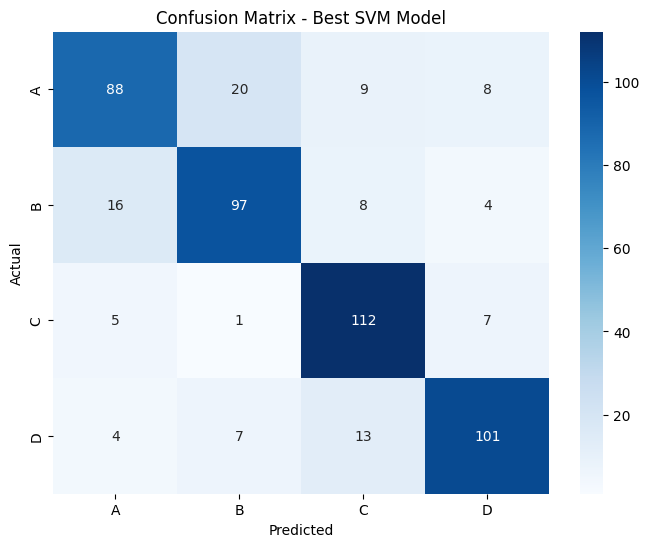


 TARGET ACHIEVED: 75% accuracy or higher! 
MODEL COMPARISON
             Model  Test Accuracy
Basic SVM (Linear)           60.8
   Tuned SVM (RBF)           79.6


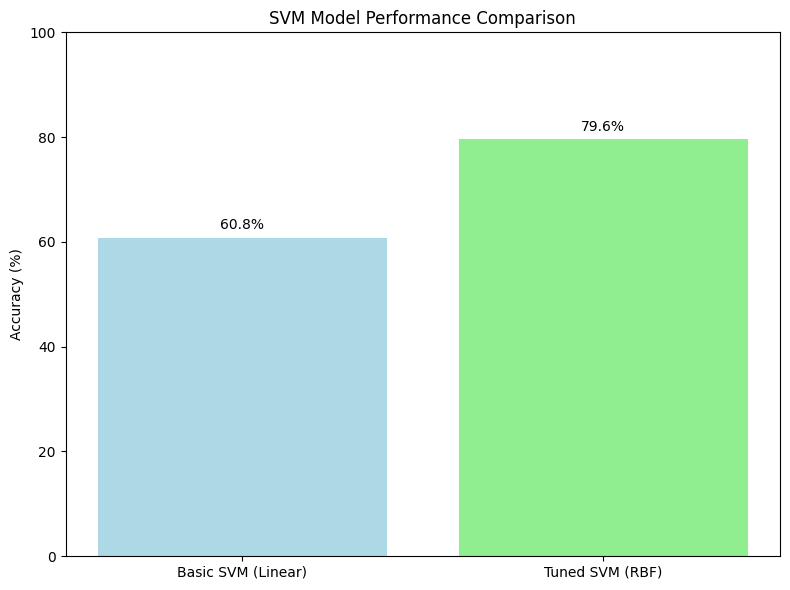

In [27]:
print("="*50)
print("FINAL MODEL EVALUATION")
print("="*50)

# Make predictions with best model
y_pred_best = best_svm.predict(X_test_scaled)

# Calculate accuracy
final_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Final Test Accuracy: {final_accuracy * 100:.2f}%")

# Classification Report
print("\n" + "="*40)
print("CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_test, y_pred_best, target_names=['A', 'B', 'C', 'D']))

# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A', 'B', 'C', 'D'],
            yticklabels=['A', 'B', 'C', 'D'])
plt.title('Confusion Matrix - Best SVM Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Check if target achieved
if final_accuracy >= 0.75:
    print("\n TARGET ACHIEVED: 75% accuracy or higher! ")
else:
    print(f"\n Current accuracy: {final_accuracy*100:.2f}%. Need more tuning.")

# Cell 14: Compare basic vs tuned model
print("="*50)
print("MODEL COMPARISON")
print("="*50)

comparison_data = {
    'Model': ['Basic SVM (Linear)', 'Tuned SVM (RBF)'],
    'Test Accuracy': [accuracy_basic * 100, final_accuracy * 100]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Visual comparison
plt.figure(figsize=(8, 6))
bars = plt.bar(comparison_df['Model'], comparison_df['Test Accuracy'],
               color=['lightblue', 'lightgreen'])
plt.ylabel('Accuracy (%)')
plt.title('SVM Model Performance Comparison')
plt.ylim(0, 100)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [26]:
print("="*50)
print("SUMMARY")
print("="*50)
print(f"Training set size: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set size: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(y.unique())}")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Improvement from basic model: {(final_accuracy - accuracy_basic) * 100:.2f}%")

SUMMARY
Training set size: 500 samples (50.0%)
Testing set size: 500 samples (50.0%)
Number of features: 20
Number of classes: 4
Best parameters found: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Improvement from basic model: 18.80%
